____
# COMPUTE GRADIENT, INTERPOLATE AND ROTATE SWOT DATA ON COLOC POINTS

In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir_2km, drifters_dir, get_proj, lonlat2xy, zarr_dir
from swot import browse_swot_2km, add_mask_inside_swot, build_swath_polygon

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

_______
# Add delay on the cycle

In [3]:
dc = 1

In [8]:
dfs = browse_swot_2km().reset_index()
drifters_sources = 'all_med_variational_10min_v0.nc'
#drifters_sources = 'all_med_lowess_10min_v0.nc'
df0 = pd.read_csv(os.path.join(zarr_dir, 'drifters_'+drifters_sources.replace('.nc', '.csv')), parse_dates=['datetime'])#.drop(columns='Unnamed: 0')


possible_cycle = np.unique(df0.pass_number.astype(str) + df0.cycle_number.astype(str))

df1 = df0.copy()
df1['cycle_number'] = (df1.cycle_number+dc).astype(int)
df1 = df1[(df1.pass_number.astype(str) + df1.cycle_number.astype(str)).isin(possible_cycle)].drop(columns=['cycle_date', 'time_to_swot'])

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_51228/2756370493.py:4: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df0 = pd.read_csv(os.path.join(zarr_dir, 'drifters_'+drifters_sources.replace('.nc', '.csv')), parse_dates=['datetime'])#.drop(columns='Unnamed: 0')


In [65]:
#rn = np.random.randint(300000, size=100)

df0_  = df0.set_index('row_number').wh
df0_ 

,pass_number,drifter_id,datetime,x,y,drifter_type,cruise_id,lonc,latc,longitude,...,acceleration_north,acceleration,X,gap_mask,gaps,inside_left,inside_right,time_to_swot,cycle_number,cycle_date
row_number,,,,,,,,,,,,,,,,,,,,,
1500,3,0-4388599,2023-04-02 14:30:00,-204332.012408,237819.878131,CARTHE,C-SWOT,7.31771,39.945366,4.849314,...,4.027357e-06,0.000007,313544.041131,1.0,-976.0,1.0,0.0,0 days 09:03:10.425673088,479,2023-04-02 23:33:10.425673088
1501,3,0-4388599,2023-04-02 14:40:00,-204304.435848,237772.730607,CARTHE,C-SWOT,7.31771,39.945366,4.849663,...,3.964133e-06,0.000006,313490.309145,1.0,-376.0,1.0,0.0,0 days 08:53:10.425673088,479,2023-04-02 23:33:10.425673088
1502,3,0-4388599,2023-04-02 14:50:00,-204275.088170,237727.010171,CARTHE,C-SWOT,7.31771,39.945366,4.850033,...,3.870204e-06,0.000006,313436.505550,1.0,224.0,1.0,0.0,0 days 08:43:10.425673088,479,2023-04-02 23:33:10.425673088
1503,3,0-4388599,2023-04-02 15:00:00,-204244.310069,237682.683008,CARTHE,C-SWOT,7.31771,39.945366,4.850420,...,3.718395e-06,0.000005,313382.826584,1.0,-667.0,1.0,0.0,0 days 08:33:10.425673088,479,2023-04-02 23:33:10.425673088
1504,3,0-4388599,2023-04-02 15:10:00,-204212.391815,237639.694468,CARTHE,C-SWOT,7.31771,39.945366,4.850820,...,3.483264e-06,0.000004,313329.419872,1.0,-67.0,1.0,0.0,0 days 08:23:10.425673088,479,2023-04-02 23:33:10.425673088
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,3,0-4388599,2023-04-03 06:20:00,-204802.745558,223549.084388,CARTHE,C-SWOT,7.31771,39.945366,4.848535,...,-6.068166e-07,0.000009,303180.404575,1.0,-131.0,1.0,0.0,0 days 06:46:49.574326912,479,2023-04-02 23:33:10.425673088
1596,3,0-4388599,2023-04-03 06:30:00,-204846.063335,223326.407635,CARTHE,C-SWOT,7.31771,39.945366,4.848090,...,-1.396644e-07,0.000009,303045.531251,1.0,-133.0,1.0,0.0,0 days 06:56:49.574326912,479,2023-04-02 23:33:10.425673088
1597,3,0-4388599,2023-04-03 06:40:00,-204886.009052,223103.680604,CARTHE,C-SWOT,7.31771,39.945366,4.847685,...,2.309500e-07,0.000010,302908.449873,1.0,-149.0,1.0,0.0,0 days 07:06:49.574326912,479,2023-04-02 23:33:10.425673088


In [69]:
df1_  = df1.set_index('row_number')[df1.pass_number==3][df1.cycle_number==480]
df1_

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_51228/852034956.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df1_  = df1.set_index('row_number')[df1.pass_number==3][df1.cycle_number==480]


,pass_number,drifter_id,datetime,x,y,drifter_type,cruise_id,lonc,latc,longitude,...,velocity,acceleration_east,acceleration_north,acceleration,X,gap_mask,gaps,inside_left,inside_right,cycle_number
row_number,,,,,,,,,,,,,,,,,,,,,
1118,3,300534060315840,2023-04-02 11:40:00,-89916.384202,16225.657691,SVP,C-SWOT,6.0070,42.049,4.918448,...,0.084280,0.000005,8.015778e-06,0.000009,91368.638578,1.0,0.0,1.0,0.0,480
1119,3,300534060315840,2023-04-02 11:50:00,-89889.715230,16183.597457,SVP,C-SWOT,6.0070,42.049,4.918777,...,0.081492,0.000004,8.552750e-06,0.000009,91334.931602,1.0,0.0,1.0,0.0,480
1120,3,300534060315840,2023-04-02 12:00:00,-89861.654485,16144.616213,SVP,C-SWOT,6.0070,42.049,4.919123,...,0.078374,0.000003,9.171938e-06,0.000010,91300.413906,1.0,0.0,1.0,0.0,480
1121,3,300534060315840,2023-04-02 12:10:00,-89832.522656,16108.936868,SVP,C-SWOT,6.0070,42.049,4.919481,...,0.074970,0.000002,9.822466e-06,0.000010,91265.436906,1.0,0.0,1.0,0.0,480
1122,3,300534060315840,2023-04-02 12:20:00,-89802.546792,16076.793609,SVP,C-SWOT,6.0070,42.049,4.919848,...,0.071426,0.000002,1.043706e-05,0.000011,91230.261992,1.0,0.0,1.0,0.0,480
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2136,3,300534060114360,2023-04-03 10:40:00,-182130.275497,-65709.480828,SVP,C-SWOT,6.9799,42.160,4.796809,...,0.286478,0.000017,3.576851e-06,0.000017,193621.210417,1.0,0.0,1.0,0.0,480
2137,3,300534060114360,2023-04-03 10:50:00,-182299.042576,-65704.111666,SVP,C-SWOT,6.9799,42.160,4.794785,...,0.276009,0.000018,2.856325e-06,0.000018,193778.149475,1.0,0.0,1.0,0.0,480
2138,3,300534060114360,2023-04-03 11:00:00,-182461.277613,-65697.714227,SVP,C-SWOT,6.9799,42.160,4.792840,...,0.264939,0.000019,2.174120e-06,0.000019,193928.614399,1.0,0.0,1.0,0.0,480


In [70]:
df0_  = df0.set_index('row_number').loc[df1_.index]
df0_ 

,pass_number,drifter_id,datetime,x,y,drifter_type,cruise_id,lonc,latc,longitude,...,acceleration_north,acceleration,X,gap_mask,gaps,inside_left,inside_right,time_to_swot,cycle_number,cycle_date
row_number,,,,,,,,,,,,,,,,,,,,,
1118,3,300534060315840,2023-04-02 11:40:00,-89916.384202,16225.657691,SVP,C-SWOT,6.0070,42.049,4.918448,...,8.015778e-06,0.000009,91368.638578,1.0,0.0,1.0,0.0,0 days 11:53:10.425673088,479,2023-04-02 23:33:10.425673088
1119,3,300534060315840,2023-04-02 11:50:00,-89889.715230,16183.597457,SVP,C-SWOT,6.0070,42.049,4.918777,...,8.552750e-06,0.000009,91334.931602,1.0,0.0,1.0,0.0,0 days 11:43:10.425673088,479,2023-04-02 23:33:10.425673088
1120,3,300534060315840,2023-04-02 12:00:00,-89861.654485,16144.616213,SVP,C-SWOT,6.0070,42.049,4.919123,...,9.171938e-06,0.000010,91300.413906,1.0,0.0,1.0,0.0,0 days 11:33:10.425673088,479,2023-04-02 23:33:10.425673088
1121,3,300534060315840,2023-04-02 12:10:00,-89832.522656,16108.936868,SVP,C-SWOT,6.0070,42.049,4.919481,...,9.822466e-06,0.000010,91265.436906,1.0,0.0,1.0,0.0,0 days 11:23:10.425673088,479,2023-04-02 23:33:10.425673088
1122,3,300534060315840,2023-04-02 12:20:00,-89802.546792,16076.793609,SVP,C-SWOT,6.0070,42.049,4.919848,...,1.043706e-05,0.000011,91230.261992,1.0,0.0,1.0,0.0,0 days 11:13:10.425673088,479,2023-04-02 23:33:10.425673088
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2136,3,300534060114360,2023-04-03 10:40:00,-182130.275497,-65709.480828,SVP,C-SWOT,6.9799,42.160,4.796809,...,3.576851e-06,0.000017,193621.210417,1.0,0.0,1.0,0.0,0 days 11:06:49.574326912,479,2023-04-02 23:33:10.425673088
2137,3,300534060114360,2023-04-03 10:50:00,-182299.042576,-65704.111666,SVP,C-SWOT,6.9799,42.160,4.794785,...,2.856325e-06,0.000018,193778.149475,1.0,0.0,1.0,0.0,0 days 11:16:49.574326912,479,2023-04-02 23:33:10.425673088
2138,3,300534060114360,2023-04-03 11:00:00,-182461.277613,-65697.714227,SVP,C-SWOT,6.9799,42.160,4.792840,...,2.174120e-06,0.000019,193928.614399,1.0,0.0,1.0,0.0,0 days 11:26:49.574326912,479,2023-04-02 23:33:10.425673088


__________
# SWOT

In [25]:
# get grid orientation and metrics
def add_grid_metrics(ds):
    """ add grid spatial metrics """

    geod = Geod(ellps="WGS84")

    lon, lat = ds.longitude, ds.latitude
    dims = lon.dims
    
    # d/dx where x is cross-track
    az12, az21, dx = geod.inv(
        lon, lat, lon.shift(num_pixels=-1), lat.shift(num_pixels=-1),
    )
    
    ds = ds.assign_coords(dx=(dims, dx), phi=(dims, az12*np.pi/180))
    
    ds["dx"] = (
        ds["dx"]
        .ffill("num_pixels")
        .where(ds["duacs_editing_flag"]<5)
    )

    # phi_lon is cross-track direction from north
    ds["phix"] = (
        ds["phi"]
        .ffill("num_pixels")
        .where(ds["duacs_editing_flag"]<5)
    )

    # d/dy where y is along-track
    az12, az21, dy = geod.inv(
        lon, lat, lon.shift(num_lines=-1), lat.shift(num_lines=-1),
    )
    
    # phiy is along-track direction from north
    ds = ds.assign_coords(phi=(dims, az12*np.pi/180))
    ds["phiy"] = (
        ds["phi"]
        .ffill("num_pixels")
        .where(ds["duacs_editing_flag"]<5)
    )
    
    ds = ds.assign_coords(dy=(dims, dy))
    
    ds["dy"] = (
        ds["dy"]
        .ffill("num_lines")
        .where(ds["duacs_editing_flag"]<5)
    )
    ds['phi']=ds['phix']
    return ds

In [71]:
dss0 = xr.open_dataset(dfs.where((dfs.pass_number==df0_.pass_number.mean())&(dfs.cycle_number==df0_.cycle_number.mean())).dropna().file.values[0])
dss0 = add_grid_metrics(dss0)

dss1 = xr.open_dataset(dfs.where((dfs.pass_number==df1_.pass_number.mean())&(dfs.cycle_number==df1_.cycle_number.mean())).dropna().file.values[0])
dss1 = add_grid_metrics(dss1)
#list(dss.keys())

/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


In [29]:
ggd_variables = ['cvl_mean_dynamic_topography_cnes_cls_22',
                'distance_to_coast',
                 'cvl_mean_sea_surface_cnes_22_hybrid',
                 'cvl_ocean_tide_fes_2022',
                 'cvl_ssha_reference',
                 'duacs_ssha_karin_2_calibrated',
                 'duacs_ssha_karin_2_filtered',
                'duacs_ssha_karin_2_oi',
                 'internal_tide_hret',
                 'mean_sea_surface_cnescls',
                 'ocean_tide_fes',
                 'ssh_karin_uncert',
                  ]

variables = ['ancillary_surface_classification_flag',
             'cross_track_distance',
             'duacs_editing_flag',
             'duacs_phase_screen',
             'duacs_phase_screen_orbit',
             'duacs_phase_screen_static',
             'duacs_relative_vorticity',
             'duacs_speed_meridional',
             'duacs_speed_meridional_abs',
             'duacs_speed_zonal',
             'duacs_speed_zonal_abs',
             'duacs_strain',
             'duacs_xcal',
             'sig0_karin_2',
             'phi',]

# Compute gradient

## Naive way

In [72]:
# Compute ggd with "naive" approach, noise will have an impact
g = 9.80665

def gradient_naive(dss, ggd_variables=None):
    if ggd_variables : dss_ggd = dss[ggd_variables]
    dx = dss_ggd.dx.mean() # meters
    dy = dss_ggd.dy.mean()
    
    dss_ggdx = (g*dss_ggd.differentiate("num_pixels")/dx).rename({v:'ggdx_'+v for v in dss_ggd}).where(~dss['duacs_ssha_karin_2_filtered'].isnull())
    dss_ggdy = (g*dss_ggd.differentiate("num_lines")/dy).rename({v:'ggdy_'+v for v in dss_ggd}).where(~dss['duacs_ssha_karin_2_filtered'].isnull())
    return xr.merge([dss_ggdx, dss_ggdy])

dss_naive0 = gradient_naive(dss0, ggd_variables).sel(num_lines=slice(90, 480))
dss_naive1 = gradient_naive(dss1, ggd_variables).sel(num_lines=slice(90, 480))

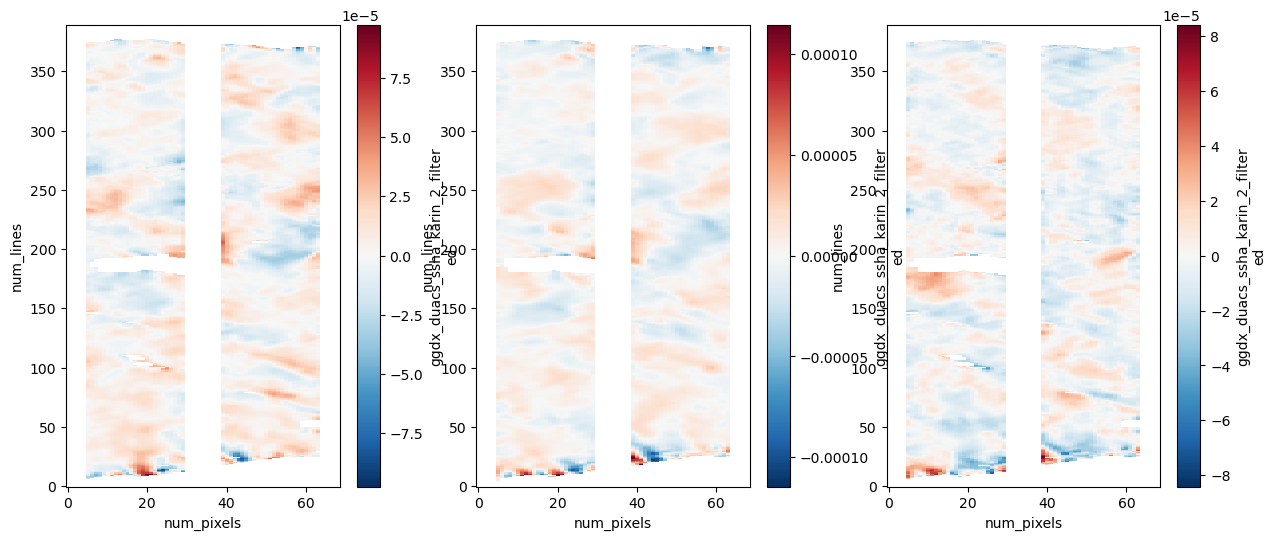

In [73]:
fig, axs = plt.subplots(1, 3, figsize = (15, 6))

dss_naive0.ggdx_duacs_ssha_karin_2_filtered.plot(ax=axs[0])
dss_naive1.ggdx_duacs_ssha_karin_2_filtered.plot(ax=axs[1])
(dss_naive1.ggdx_duacs_ssha_karin_2_filtered-dss_naive0.ggdx_duacs_ssha_karin_2_filtered).plot(ax=axs[2])

# Interpolate 

In [74]:
#dfr = pd.read_csv(os.path.join(zarr_dir, 'drifters_'+drifters_sources.replace('.nc', '.csv')))#.drop(columns = 'Unnamed: 0').set_index('row_number')

In [75]:
#dfr_ = dfr.where((dfr.pass_number==swath)&(dfr.cycle_number==cycle)).dropna()

In [76]:
import pyinterp
mesh = pyinterp.RTree()

def interp_one_dataarray(da, new_lon, new_lat):
    lons = da.longitude.compute().data.flatten()
    lats = da.latitude.compute().data.flatten()
    data = da.compute().data.flatten()

    mesh.packing(np.vstack((lons, lats)).T, data)
    mx = new_lon
    my = new_lat

    idw, neighbors = mesh.inverse_distance_weighting(
        np.vstack((mx.ravel(), my.ravel())).T,
        within=False,  # Extrapolation is forbidden
        k=5,  # We are looking for at most 11 neighbors
        num_threads=0,
    )
    idw = idw.reshape(mx.shape)
    return idw

def interp_dss(dss, new_lon, new_lat):
    df_interp = pd.DataFrame()
    df_interp['longitude'] = new_lon
    df_interp['latitude'] = new_lat
    for v in dss : 
        da = dss[v]
        df_interp[v]=interp_one_dataarray(da, new_lon, new_lat)
    return df_interp
        
        

____________
# Compute and interp at once

In [77]:
def coloc_swot_cycle_swath(dfr, dfs, cycle, swath, cutoff, method_gradient='gauss'):
    # select drifter point
    dfr_ = dfr.where((dfr.pass_number==swath)&(dfr.cycle_number==cycle)).dropna()
    try : 
        dss = xr.open_dataset(dfs.where((dfs.pass_number==swath)&(dfs.cycle_number==cycle)).dropna().file.values[0])
    except : 
        dss = dss_nan
        print(swath, cycle)
    dss = add_grid_metrics(dss).reset_coords(['phi'])
    if method_gradient =='naive' :
        dss_ggd= gradient_naive(dss, ggd_variables=ggd_variables)
    if method_gradient == 'gauss' :
        dss_ggd = gradient_gauss(dss, cutoff, ggd_variables)
    swot_time = pd.to_datetime(dss.time.values[0])
    dss = xr.merge([dss[variables], dss_ggd])
    df_interp = interp_dss(dss, dfr_.longitude.values, dfr_.latitude.values)
    df_out = pd.concat([dfr_.reset_index()[['row_number', 'longitude']].set_index('longitude'), df_interp.set_index('longitude')], axis=1).reset_index().set_index('row_number')
    rotate_ggd(df_out)
    df_out['time_to_swot_update']=(dfr_.datetime-swot_time).abs()
    return df_out

def coloc_swot(dfr, dfs, cutoff, method_gradient='gauss'):
    DF = []
    for swath in dfr.pass_number.unique() : 
        for cycle in dfr.where(dfr.pass_number==swath).dropna().cycle_number.unique():
            DF.append(coloc_swot_cycle_swath(dfr, dfs, cycle,  swath, cutoff, method_gradient))
    return pd.concat(DF)

# Rotate

In [78]:
def rotate(x, y, phi):
    return np.sin(phi)*x - np.cos(phi)*y, np.cos(phi)*x + np.sin(phi)*y
def rotate_ggd(df):
    for v in ggd_variables : 
        df['ggde_'+v], df['ggdn_'+v] = rotate(df['ggdx_'+v], df['ggdy_'+v], df['phi'])

__________
________
# GENERATE


In [79]:
method, cutoff = 'naive', ''
dfsg0 = coloc_swot(df0_, dfs, method_gradient=method, cutoff=cutoff)
rotate_ggd(dfsg0)

dfsg1 = coloc_swot(df1_, dfs, method_gradient=method, cutoff=cutoff)
rotate_ggd(dfsg1)


/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


In [80]:
dfsg0.ggdx_duacs_ssha_karin_2_filtered

row_number
1118    0.000004
1119    0.000004
1120    0.000004
1121    0.000004
1122    0.000004
          ...   
2136         NaN
2137         NaN
2138         NaN
2139         NaN
2140         NaN
Name: ggdx_duacs_ssha_karin_2_filtered, Length: 1023, dtype: float64

In [81]:
dfsg1.ggdx_duacs_ssha_karin_2_filtered

row_number
1118    0.000005
1119    0.000005
1120    0.000005
1121    0.000005
1122    0.000005
          ...   
2136         NaN
2137         NaN
2138         NaN
2139         NaN
2140         NaN
Name: ggdx_duacs_ssha_karin_2_filtered, Length: 1023, dtype: float64

In [50]:
dfsg1.columns

Index(['longitude', 'latitude', 'ancillary_surface_classification_flag',
       'cross_track_distance', 'duacs_editing_flag', 'duacs_phase_screen',
       'duacs_phase_screen_orbit', 'duacs_phase_screen_static',
       'duacs_relative_vorticity', 'duacs_speed_meridional',
       'duacs_speed_meridional_abs', 'duacs_speed_zonal',
       'duacs_speed_zonal_abs', 'duacs_strain', 'duacs_xcal', 'sig0_karin_2',
       'phi', 'ggdx_cvl_mean_dynamic_topography_cnes_cls_22',
       'ggdx_distance_to_coast', 'ggdx_cvl_mean_sea_surface_cnes_22_hybrid',
       'ggdx_cvl_ocean_tide_fes_2022', 'ggdx_cvl_ssha_reference',
       'ggdx_duacs_ssha_karin_2_calibrated',
       'ggdx_duacs_ssha_karin_2_filtered', 'ggdx_duacs_ssha_karin_2_oi',
       'ggdx_internal_tide_hret', 'ggdx_mean_sea_surface_cnescls',
       'ggdx_ocean_tide_fes', 'ggdx_ssh_karin_uncert',
       'ggdy_cvl_mean_dynamic_topography_cnes_cls_22',
       'ggdy_distance_to_coast', 'ggdy_cvl_mean_sea_surface_cnes_22_hybrid',
       'ggdy_c

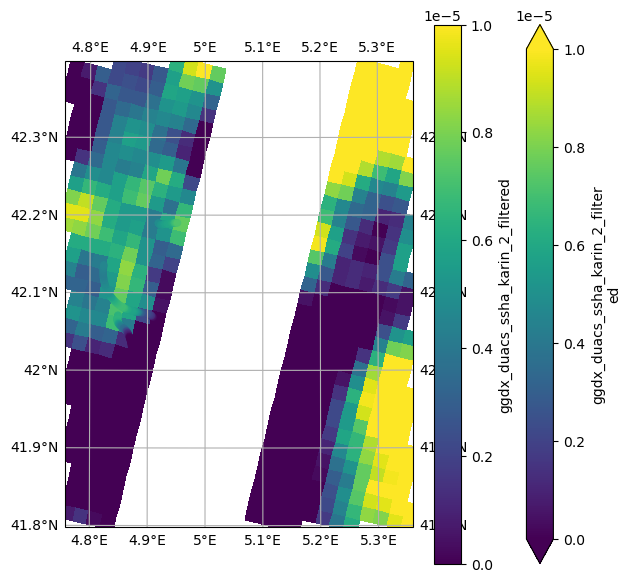

In [88]:
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection=ccrs.Orthographic(df1_.longitude.mean(), df1_.latitude.mean()))
ax.add_feature(cfeature.LAND,)
dl=0.3
bbox = [df1_.longitude.mean()-dl,df1_.longitude.mean()+dl, df1_.latitude.mean()-dl, df1_.latitude.mean()+dl]
dss_naive1_  =dss_naive1.where((dss_naive1.latitude>bbox[2]) & (dss_naive1.latitude<bbox[3])&(dss_naive1.longitude>bbox[0]) & (dss_naive1.longitude<bbox[1]))
dss_naive1_.ggdx_duacs_ssha_karin_2_filtered.plot(x = 'longitude', y='latitude', ax=ax, transform=crs, cmap='viridis', vmin=0, vmax=1e-5)
gl = ax.gridlines(draw_labels=True,)
dfsg1.plot.scatter(x = 'longitude', y='latitude', ax=ax, transform=crs, c='ggdx_duacs_ssha_karin_2_filtered', cmap='viridis', vmin=0, vmax=1e-5)

ax.set_extent(bbox)

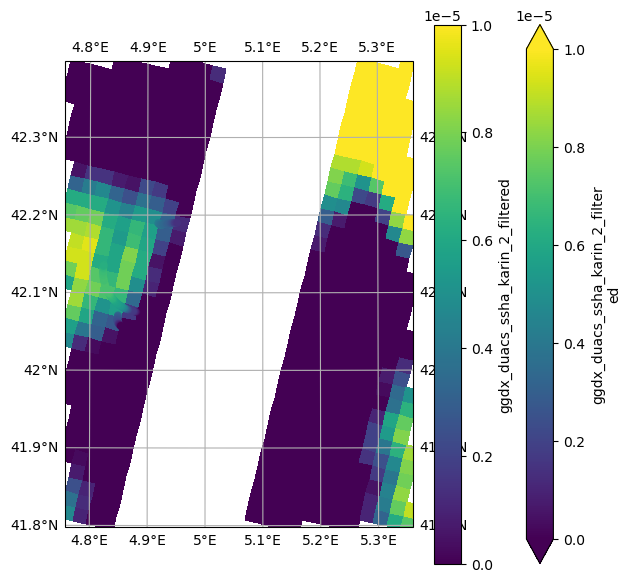

In [90]:
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection=ccrs.Orthographic(df0_.longitude.mean(), df0_.latitude.mean()))
ax.add_feature(cfeature.LAND,)
dl=0.3
bbox = [df0_.longitude.mean()-dl,df0_.longitude.mean()+dl, df0_.latitude.mean()-dl, df0_.latitude.mean()+dl]
dss_naive0_  =dss_naive0.where((dss_naive0.latitude>bbox[2]) & (dss_naive0.latitude<bbox[3])&(dss_naive0.longitude>bbox[0]) & (dss_naive0.longitude<bbox[1]))
dss_naive0_.ggdx_duacs_ssha_karin_2_filtered.plot(x = 'longitude', y='latitude', ax=ax, transform=crs,cmap='viridis', vmin=0, vmax=1e-5 )
gl = ax.gridlines(draw_labels=True,)
dfsg0.plot.scatter(x = 'longitude', y='latitude', ax=ax, transform=crs, c='ggdx_duacs_ssha_karin_2_filtered', cmap='viridis', vmin=0, vmax=1e-5)

ax.set_extent(bbox)

In [92]:
(dfsg0.ggdx_duacs_ssha_karin_2_filtered**2).mean()

5.687582390393828e-11

In [93]:
(dfsg1.ggdx_duacs_ssha_karin_2_filtered**2).mean()

3.793125527118804e-11